# Test Exhaustivo HMM - Electricity Dataset

**Validación Pipeline RITMO (Pasos 1-3)**

- Paso 1: Normalización Rev IN (reversible)
- Paso 2: Entrenamiento HMM (Baum-Welch con emisiones gaussianas)
- Paso 3: Tokenización Viterbi (estados óptimos)

## Dataset: Electricity
- Dominio: Consumo eléctrico MT_320 (hourly variant)
- Objetivo: Validar robustez RevIN ante distribution shift
- Regímenes: Temperatura alta/media/baja con transiciones estacionales
- Tamaño: 18,412 timesteps

## Configuraciones
- **K** ∈ {3, 4, 5, 6, 7, 8, 9} - Ejecutar cada K en celda separada
- **seeds** ∈ {42, 123, 456}
- **data_configs**: full (8640), half (4320)
- **Total**: 7 × 3 × 1 = 21 configuraciones

In [1]:
"""Imports y definiciones de funciones."""

import numpy as np
import pickle
import os
from data_provider.data_loader import Dataset_Custom
from utils.revin import RevINNormalizer
from hmm import baum_welch, viterbi_decode


class Args:
    """Mock args requerido por Dataset_Custom."""
    augmentation_ratio = 0


def load_electricity(root_path='dataset/electricity/',
               data_path='electricity.csv',
               target='OT',
               data_size=None):
    """Carga Electricity univariado sin normalización."""
    dataset_train = Dataset_Custom(
        args=Args(), root_path=root_path, flag='train', size=None,
        features='S', data_path=data_path, target=target,
        scale=False, timeenc=0, freq='h'
    )
    dataset_val = Dataset_Custom(
        args=Args(), root_path=root_path, flag='val', size=None,
        features='S', data_path=data_path, target=target,
        scale=False, timeenc=0, freq='h'
    )
    dataset_test = Dataset_Custom(
        args=Args(), root_path=root_path, flag='test', size=None,
        features='S', data_path=data_path, target=target,
        scale=False, timeenc=0, freq='h'
    )

    train = dataset_train.data_x.flatten()
    val = dataset_val.data_x.flatten()
    test = dataset_test.data_x.flatten()

    if data_size is not None:
        train = train[:data_size]

    return {'train': train, 'val': val, 'test': test}


def validate_revin(data_original, data_normalized, normalizer, split='train', threshold=1e-6):
    """Valida reversibilidad normalización RevIN."""
    success, mse = normalizer.validate_reconstruction(
        original=data_original,
        normalized=data_normalized,
        split=split,
        threshold=threshold
    )
    return success, mse


def validate_hmm_params(params, K):
    """Valida validez matemática parámetros HMM λ = (A, π, μ, σ)."""
    checks = {}
    row_sums = np.sum(params['A'], axis=1)
    checks['matrix_stochastic'] = np.allclose(row_sums, 1.0, atol=1e-4)
    checks['pi_stochastic'] = np.isclose(np.sum(params['pi']), 1.0, atol=1e-4)
    checks['sigma_positive'] = np.all(params['sigma'] > 0)
    checks['mu_finite'] = np.all(np.isfinite(params['mu']))
    checks['dims_correct'] = (
        params['A'].shape == (K, K) and params['pi'].shape == (K,) and
        params['mu'].shape == (K,) and params['sigma'].shape == (K,)
    )
    checks['no_extreme_persistence'] = np.all(np.diag(params['A']) < 0.99)
    checks['sigma_reasonable'] = np.all((params['sigma'] > 0.05) & (params['sigma'] < 10.0))
    checks['mu_spread'] = (params['mu'].max() - params['mu'].min()) > 0.5
    return checks


def validate_viterbi(states_pred, K, data_norm):
    """Valida output de Viterbi Q* = argmax P(Q|O,λ)."""
    checks = {}
    checks['length_match'] = len(states_pred) == len(data_norm)
    checks['states_in_range'] = np.all((states_pred >= 0) & (states_pred < K))
    checks['states_finite'] = np.all(np.isfinite(states_pred))
    n_segments = np.sum(np.diff(states_pred) != 0) + 1
    checks['has_segments'] = n_segments >= 1
    return checks


def run_single_config(K, seed, data_config, verbose=False):
    """Ejecuta pipeline completo para una configuración (K, seed, data_size)."""
    if verbose:
        print(f"\n{'='*60}")
        print(f"CONFIG: K={K}, seed={seed}, data={data_config['name']}")
        print(f"{'='*60}")

    data = load_electricity(data_size=data_config['size'])
    train_size = len(data['train'])

    if verbose:
        print(f"Train size: {train_size} timesteps")

    normalizer = RevINNormalizer(num_features=1, eps=1e-5, affine=False)
    data_norm = normalizer.fit_transform(
        train_data=data['train'],
        val_data=data['val'],
        test_data=data['test']
    )

    revin_success, revin_mse = validate_revin(
        data['train'], data_norm['train'], normalizer, split='train'
    )

    if verbose:
        status = "✓" if revin_success else "✗"
        print(f"{status} RevIN MSE: {revin_mse:.2e}")

    params = baum_welch(
        data_norm['train'], K=K, max_iter=300, epsilon=1e-4,
        random_state=seed, verbose=False
    )

    hmm_checks = validate_hmm_params(params, K)

    if verbose:
        status = "✓" if params['converged'] else "⚠"
        print(f"{status} HMM convergió: {params['converged']} ({params['n_iter']} iter)")

    states_pred, log_likelihood = viterbi_decode(
        data_norm['train'], params['A'], params['pi'],
        params['mu'], params['sigma']
    )

    viterbi_checks = validate_viterbi(states_pred, K, data_norm['train'])

    unique_states = len(np.unique(states_pred))
    n_segments = np.sum(np.diff(states_pred) != 0) + 1
    n_tokens_llm = len(states_pred)
    compression_ratio = len(states_pred) / n_segments
    avg_segment_duration = len(states_pred) / n_segments

    viterbi_checks['no_degenerate_states'] = unique_states >= K * 0.7
    hmm_checks['no_degenerate_states'] = unique_states >= K * 0.7

    num_params = K**2 + 2*K
    AIC = -2 * log_likelihood + 2 * num_params
    BIC = -2 * log_likelihood + np.log(len(states_pred)) * num_params

    state_counts = np.bincount(states_pred, minlength=K)
    state_distribution = state_counts / len(states_pred)
    state_entropy = -np.sum(state_distribution * np.log(state_distribution + 1e-10))

    if verbose:
        status = "✓" if not np.isnan(log_likelihood) else "✗"
        print(f"{status} Log-likelihood: {log_likelihood:.2f}")
        print(f"  AIC: {AIC:.2f}, BIC: {BIC:.2f}")
        print(f"  Estados activos: {unique_states}/{K}")
        print(f"  Entropía: {state_entropy:.3f}, Segmentos: {n_segments}")
        print(f"  Compresión: {compression_ratio:.1f}x")

    return {
        'K': K, 'seed': seed, 'data_config': data_config['name'],
        'train_size': train_size, 'revin_success': revin_success,
        'revin_mse': revin_mse, 'hmm_converged': params['converged'],
        'hmm_n_iter': params['n_iter'], 'hmm_checks': hmm_checks,
        'log_likelihood': log_likelihood, 'AIC': AIC, 'BIC': BIC,
        'unique_states': unique_states, 'n_tokens_llm': n_tokens_llm,
        'n_segments': n_segments, 'compression_ratio': compression_ratio,
        'avg_segment_duration': avg_segment_duration,
        'state_entropy': state_entropy, 'viterbi_checks': viterbi_checks,
        'data_raw': data['train'], 'data_norm': data_norm['train'],
        'states': states_pred, 'params': params
    }


def print_summary(results):
    """Imprime reporte consolidado de todas las configuraciones."""
    print("\n" + "="*80)
    print("REPORTE EXHAUSTIVO - VALIDACIÓN PASOS 1-3")
    print("="*80)

    total_configs = len(results)
    revin_passed = sum(1 for r in results if r['revin_success'])
    hmm_converged = sum(1 for r in results if r['hmm_converged'])

    print(f"\nTotal configuraciones: {total_configs}")
    print(f"\n{'='*80}")
    print("PASO 1: REVIN NORMALIZACIÓN")
    print(f"{'='*80}")
    print(f"✓ Pasadas: {revin_passed}/{total_configs} ({100*revin_passed/total_configs:.1f}%)")

    mse_values = [r['revin_mse'] for r in results]
    print(f"  MSE min: {min(mse_values):.2e}")
    print(f"  MSE max: {max(mse_values):.2e}")
    print(f"  MSE mean: {np.mean(mse_values):.2e}")

    print(f"\n{'='*80}")
    print("PASO 2: HMM ENTRENAMIENTO")
    print(f"{'='*80}")
    print(f"✓ Convergió: {hmm_converged}/{total_configs} ({100*hmm_converged/total_configs:.1f}%)")

    hmm_checks_all = [r['hmm_checks'] for r in results]
    check_names = list(hmm_checks_all[0].keys())
    for check_name in check_names:
        check_passed = sum(1 for r in results if r['hmm_checks'][check_name])
        status = "✓" if check_passed == total_configs else "✗"
        print(f"{status} {check_name}: {check_passed}/{total_configs}")

    print(f"\n{'='*80}")
    print("PASO 3: VITERBI TOKENIZACIÓN")
    print(f"{'='*80}")

    viterbi_checks_all = [r['viterbi_checks'] for r in results]
    viterbi_check_names = list(viterbi_checks_all[0].keys())
    for check_name in viterbi_check_names:
        check_passed = sum(1 for r in results if r['viterbi_checks'][check_name])
        status = "✓" if check_passed == total_configs else "✗"
        print(f"{status} {check_name}: {check_passed}/{total_configs}")

    print(f"\n{'='*90}")
    print("TABLA COMPARATIVA - ANÁLISIS POR K")
    print(f"{'='*90}")

    print(f"\n{' ':<6} {' ':<10} {' ':<8} {' ':<12} {' ':<12} {' ':<10} {' ':<10}")
    print(f"{'K':<6} {'LL (mean)':<10} {'Conv':<8} {'AIC (mean)':<12} {'BIC (mean)':<12} {'Compresión':<10} {'Estados'}")
    print("-" * 90)

    K_values = sorted(set(r['K'] for r in results))
    for K in K_values:
        K_results = [r for r in results if r['K'] == K]
        ll_values = [r['log_likelihood'] for r in K_results if not np.isnan(r['log_likelihood'])]
        aic_values = [r['AIC'] for r in K_results if not np.isnan(r['AIC'])]
        bic_values = [r['BIC'] for r in K_results if not np.isnan(r['BIC'])]
        compression_values = [r['compression_ratio'] for r in K_results]
        states_values = [r['unique_states'] for r in K_results]
        converged = sum(1 for r in K_results if r['hmm_converged'])
        total = len(K_results)

        print(f"{K:<6} {np.mean(ll_values):<10.1f} {converged}/{total:<5} "
              f"{np.mean(aic_values):<12.1f} {np.mean(bic_values):<12.1f} "
              f"{np.mean(compression_values):<10.1f}x {np.mean(states_values):.1f}/{K}")

    print(f"\n{'='*90}")
    print("RECOMENDACIÓN AUTOMÁTICA (criterios AIC/BIC)")
    print(f"{'='*90}")

    best_bic_result = min(results, key=lambda r: r['BIC'] if not np.isnan(r['BIC']) else float('inf'))
    best_aic_result = min(results, key=lambda r: r['AIC'] if not np.isnan(r['AIC']) else float('inf'))

    print(f"\n✓ Mejor K según BIC: K={best_bic_result['K']}")
    print(f"  BIC: {best_bic_result['BIC']:.2f}")
    print(f"  Log-likelihood: {best_bic_result['log_likelihood']:.2f}")
    print(f"  Compresión: {best_bic_result['compression_ratio']:.1f}x")
    print(f"  Estados activos: {best_bic_result['unique_states']}/{best_bic_result['K']}")

    print(f"\n✓ Mejor K según AIC: K={best_aic_result['K']}")
    print(f"  AIC: {best_aic_result['AIC']:.2f}")
    print(f"  Log-likelihood: {best_aic_result['log_likelihood']:.2f}")
    print(f"  Compresión: {best_aic_result['compression_ratio']:.1f}x")
    print(f"  Estados activos: {best_aic_result['unique_states']}/{best_aic_result['K']}")

    print(f"\n{'='*80}")
    print("VERIFICACIÓN FINAL")
    print(f"{'='*80}")

    all_passed = (
        revin_passed == total_configs and
        all(all(r['hmm_checks'].values()) for r in results) and
        all(all(r['viterbi_checks'].values()) for r in results)
    )

    if all_passed:
        print("✓ TODOS LOS TESTS PASADOS - PASOS 1-3 VALIDADOS AL 100%")
    else:
        print("✗ ALGUNOS TESTS FALLARON - REVISAR CONFIGURACIONES")

    print("="*80 + "\n")


print("✓ Funciones cargadas correctamente")

✓ Funciones cargadas correctamente


In [2]:
"""Configuración inicial y sistema de caché."""

print("="*80)
print("TEST EXHAUSTIVO HMM - ETTH2 + RevIN")
print("="*80)
print("\nValidando Pipeline RITMO (Pasos 1-3):")
print("  1. Normalización RevIN")
print("  2. Entrenamiento HMM (Baum-Welch)")
print("  3. Tokenización (Viterbi)")
print("\nDataset: Electricity")
print("  - Periodicidad 24h (día/noche)")
print("  - Regímenes de consumo diferenciados")

# Configuración global
K_VALUES = list(range(3, 10))  # K=3 a K=9
SEEDS = [42, 123, 456]
DATA_CONFIGS = [
    {'name': 'full', 'size': None},
    {'name': 'half', 'size': 4320}
]

print(f"\nConfiguración:")
print(f"  K values: {K_VALUES}")
print(f"  Seeds: {SEEDS}")
print(f"  Data configs: {[d['name'] for d in DATA_CONFIGS]}")
print(f"  Total configuraciones: {len(K_VALUES) * len(SEEDS) * len(DATA_CONFIGS)}")

# Inicializar lista de resultados
if 'results' not in globals():
    results = []

# Sistema de caché
CACHE_FILE = './cache/results_electricity.pkl'
os.makedirs('./cache', exist_ok=True)

# Cargar resultados previos si existen
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'rb') as f:
        results = pickle.load(f)
    print(f"\n✓ Cargados {len(results)} resultados del caché")
    
    # Mostrar qué K ya están completados
    K_completed = {}
    for K in K_VALUES:
        K_results = [r for r in results if r['K'] == K]
        K_completed[K] = len(K_results)
    
    print("\nEstado actual:")
    expected_per_K = len(SEEDS) * len(DATA_CONFIGS)
    for K in K_VALUES:
        count = K_completed.get(K, 0)
        status = "✓" if count == expected_per_K else "⚠"
        print(f"  {status} K={K}: {count}/{expected_per_K} configuraciones")
else:
    print("\n⚠ No hay caché previo. Empezando desde cero.")

print("\n" + "="*80)
print("Ejecuta las celdas de K individuales para correr experimentos")
print("="*80)

TEST EXHAUSTIVO HMM - ETTH2 + RevIN

Validando Pipeline RITMO (Pasos 1-3):
  1. Normalización RevIN
  2. Entrenamiento HMM (Baum-Welch)
  3. Tokenización (Viterbi)

Dataset: Electricity
  - Periodicidad 24h (día/noche)
  - Regímenes de consumo diferenciados

Configuración:
  K values: [3, 4, 5, 6, 7, 8, 9]
  Seeds: [42, 123, 456]
  Data configs: ['full', 'half']
  Total configuraciones: 42

✓ Cargados 34 resultados del caché

Estado actual:
  ✓ K=3: 6/6 configuraciones
  ✓ K=4: 6/6 configuraciones
  ✓ K=5: 6/6 configuraciones
  ✓ K=6: 6/6 configuraciones
  ✓ K=7: 6/6 configuraciones
  ⚠ K=8: 4/6 configuraciones
  ⚠ K=9: 0/6 configuraciones

Ejecuta las celdas de K individuales para correr experimentos


In [3]:
# ========================================
# EJECUTAR K=3
# ========================================

K = 3
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

# Verificar si ya está completado
existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    # Ejecutar configuraciones para este K
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            # Verificar si esta config específica ya existe
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            # Guardar en caché después de cada ejecución
            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=3

  Ejecutando K=3, seed=42, data=full...

CONFIG: K=3, seed=42, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (37 iter)
✓ Log-likelihood: -14699.59
  AIC: 29429.18, BIC: 29546.49
  Estados activos: 3/3
  Entropía: 1.049, Segmentos: 1343
  Compresión: 13.7x

  Ejecutando K=3, seed=42, data=half...

CONFIG: K=3, seed=42, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (37 iter)
✓ Log-likelihood: -3915.65
  AIC: 7861.30, BIC: 7956.86
  Estados activos: 3/3
  Entropía: 0.974, Segmentos: 364
  Compresión: 11.9x

  Ejecutando K=3, seed=123, data=full...

CONFIG: K=3, seed=123, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (37 iter)
✓ Log-likelihood: -14699.59
  AIC: 29429.18, BIC: 29546.49
  Estados activos: 3/3
  Entropía: 1.049, Segmentos: 1343
  Compresión: 13.7x

  Ejecutando K=3, seed=123, data=half...

CONFIG: K=3, seed=123, data=half
Train size: 4320 timesteps
✓ Rev

In [4]:
# ========================================
# EJECUTAR K=4
# ========================================

K = 4
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=4

  Ejecutando K=4, seed=42, data=full...

CONFIG: K=4, seed=42, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (94 iter)
✓ Log-likelihood: -12192.75
  AIC: 24433.51, BIC: 24621.21
  Estados activos: 4/4
  Entropía: 1.361, Segmentos: 2139
  Compresión: 8.6x

  Ejecutando K=4, seed=42, data=half...

CONFIG: K=4, seed=42, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (99 iter)
✓ Log-likelihood: -3402.28
  AIC: 6852.57, BIC: 7005.47
  Estados activos: 4/4
  Entropía: 1.289, Segmentos: 505
  Compresión: 8.6x

  Ejecutando K=4, seed=123, data=full...

CONFIG: K=4, seed=123, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (94 iter)
✓ Log-likelihood: -12192.76
  AIC: 24433.51, BIC: 24621.21
  Estados activos: 4/4
  Entropía: 1.361, Segmentos: 2139
  Compresión: 8.6x

  Ejecutando K=4, seed=123, data=half...

CONFIG: K=4, seed=123, data=half
Train size: 4320 timesteps
✓ RevIN 

In [5]:
# ========================================
# EJECUTAR K=5
# ========================================

K = 5
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=5

  Ejecutando K=5, seed=42, data=full...

CONFIG: K=5, seed=42, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (177 iter)
✓ Log-likelihood: -10461.81
  AIC: 20993.61, BIC: 21267.34
  Estados activos: 5/5
  Entropía: 1.583, Segmentos: 2854
  Compresión: 6.5x

  Ejecutando K=5, seed=42, data=half...

CONFIG: K=5, seed=42, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (72 iter)
✓ Log-likelihood: -3042.81
  AIC: 6155.61, BIC: 6378.60
  Estados activos: 5/5
  Entropía: 1.526, Segmentos: 689
  Compresión: 6.3x

  Ejecutando K=5, seed=123, data=full...

CONFIG: K=5, seed=123, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (177 iter)
✓ Log-likelihood: -10461.81
  AIC: 20993.61, BIC: 21267.34
  Estados activos: 5/5
  Entropía: 1.583, Segmentos: 2854
  Compresión: 6.5x

  Ejecutando K=5, seed=123, data=half...

CONFIG: K=5, seed=123, data=half
Train size: 4320 timesteps
✓ RevI

In [3]:
# ========================================
# EJECUTAR K=6
# ========================================

K = 6
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=6

  Ejecutando K=6, seed=42, data=full...

CONFIG: K=6, seed=42, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (159 iter)
✓ Log-likelihood: -9229.13
  AIC: 18554.26, BIC: 18929.66
  Estados activos: 6/6
  Entropía: 1.756, Segmentos: 3616
  Compresión: 5.1x

  Ejecutando K=6, seed=42, data=half...

CONFIG: K=6, seed=42, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (95 iter)
✓ Log-likelihood: -3003.46
  AIC: 6102.93, BIC: 6408.74
  Estados activos: 6/6
  Entropía: 1.631, Segmentos: 880
  Compresión: 4.9x

  Ejecutando K=6, seed=123, data=full...

CONFIG: K=6, seed=123, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (141 iter)
✓ Log-likelihood: -9229.16
  AIC: 18554.32, BIC: 18929.72
  Estados activos: 6/6
  Entropía: 1.756, Segmentos: 3616
  Compresión: 5.1x

  Ejecutando K=6, seed=123, data=half...

CONFIG: K=6, seed=123, data=half
Train size: 4320 timesteps
✓ RevIN 

In [3]:
# ========================================
# EJECUTAR K=7
# ========================================

K = 7
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=7
  ⏭ K=7, seed=42, data=full ya existe
  ⏭ K=7, seed=42, data=half ya existe
  ⏭ K=7, seed=123, data=full ya existe
  ⏭ K=7, seed=123, data=half ya existe

  Ejecutando K=7, seed=456, data=full...

CONFIG: K=7, seed=456, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (280 iter)
✓ Log-likelihood: -8485.62
  AIC: 17097.25, BIC: 17589.96
  Estados activos: 7/7
  Entropía: 1.881, Segmentos: 3987
  Compresión: 4.6x

  Ejecutando K=7, seed=456, data=half...

CONFIG: K=7, seed=456, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (211 iter)
✓ Log-likelihood: -2775.32
  AIC: 5676.65, BIC: 6078.02
  Estados activos: 7/7
  Entropía: 1.743, Segmentos: 984
  Compresión: 4.4x

✓ K=7 completado. Total resultados: 30


In [3]:
# ========================================
# EJECUTAR K=8
# ========================================

K = 8
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=8
  ⏭ K=8, seed=42, data=full ya existe
  ⏭ K=8, seed=42, data=half ya existe
  ⏭ K=8, seed=123, data=full ya existe
  ⏭ K=8, seed=123, data=half ya existe

  Ejecutando K=8, seed=456, data=full...

CONFIG: K=8, seed=456, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (228 iter)
✓ Log-likelihood: -7626.28
  AIC: 15412.56, BIC: 16038.22
  Estados activos: 8/8
  Entropía: 1.925, Segmentos: 4327
  Compresión: 4.3x

  Ejecutando K=8, seed=456, data=half...

CONFIG: K=8, seed=456, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (178 iter)
✓ Log-likelihood: -2550.10
  AIC: 5260.20, BIC: 5769.88
  Estados activos: 8/8
  Entropía: 1.860, Segmentos: 1162
  Compresión: 3.7x

✓ K=8 completado. Total resultados: 36


In [4]:
# ========================================
# EJECUTAR K=9
# ========================================

K = 9
print(f"\n{'='*80}")
print(f"EJECUTANDO K={K}")
print(f"{'='*80}")

existing_K = [r for r in results if r['K'] == K]
expected_configs = len(SEEDS) * len(DATA_CONFIGS)

if len(existing_K) == expected_configs:
    print(f"⚠ K={K} ya completado ({len(existing_K)} configs). Saltando...")
else:
    for seed in SEEDS:
        for data_config in DATA_CONFIGS:
            exists = any(r for r in results if r['K']==K and r['seed']==seed
                        and r['data_config']==data_config['name'])
            if exists:
                print(f"  ⏭ K={K}, seed={seed}, data={data_config['name']} ya existe")
                continue

            print(f"\n  Ejecutando K={K}, seed={seed}, data={data_config['name']}...")
            result = run_single_config(K, seed, data_config, verbose=True)
            results.append(result)

            with open(CACHE_FILE, 'wb') as f:
                pickle.dump(results, f)

    print(f"\n✓ K={K} completado. Total resultados: {len(results)}")


EJECUTANDO K=9

  Ejecutando K=9, seed=42, data=full...

CONFIG: K=9, seed=42, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (217 iter)
✓ Log-likelihood: -6772.18
  AIC: 13742.35, BIC: 14516.61
  Estados activos: 9/9
  Entropía: 2.053, Segmentos: 5029
  Compresión: 3.7x

  Ejecutando K=9, seed=42, data=half...

CONFIG: K=9, seed=42, data=half
Train size: 4320 timesteps
✓ RevIN MSE: 0.00e+00
✓ HMM convergió: True (255 iter)
✓ Log-likelihood: -2414.97
  AIC: 5027.94, BIC: 5658.67
  Estados activos: 9/9
  Entropía: 2.012, Segmentos: 1511
  Compresión: 2.9x

  Ejecutando K=9, seed=123, data=full...

CONFIG: K=9, seed=123, data=full
Train size: 18412 timesteps
✓ RevIN MSE: 8.09e-13
✓ HMM convergió: True (220 iter)
✓ Log-likelihood: -6772.18
  AIC: 13742.36, BIC: 14516.61
  Estados activos: 9/9
  Entropía: 2.053, Segmentos: 5029
  Compresión: 3.7x

  Ejecutando K=9, seed=123, data=half...

CONFIG: K=9, seed=123, data=half
Train size: 4320 timesteps
✓ RevI

In [7]:
# ========================================
# RESUMEN CONSOLIDADO
# ========================================

if len(results) > 0:
    print_summary(results)
else:
    print("⚠ No hay resultados para mostrar. Ejecuta las celdas de K primero.")


REPORTE EXHAUSTIVO - VALIDACIÓN PASOS 1-3

Total configuraciones: 42

PASO 1: REVIN NORMALIZACIÓN
✓ Pasadas: 42/42 (100.0%)
  MSE min: 0.00e+00
  MSE max: 8.09e-13
  MSE mean: 4.05e-13

PASO 2: HMM ENTRENAMIENTO
✓ Convergió: 41/42 (97.6%)
✓ matrix_stochastic: 42/42
✓ pi_stochastic: 42/42
✓ sigma_positive: 42/42
✓ mu_finite: 42/42
✓ dims_correct: 42/42
✓ no_extreme_persistence: 42/42
✗ sigma_reasonable: 33/42
✓ mu_spread: 42/42
✓ no_degenerate_states: 42/42

PASO 3: VITERBI TOKENIZACIÓN
✓ length_match: 42/42
✓ states_in_range: 42/42
✓ states_finite: 42/42
✓ has_segments: 42/42
✓ no_degenerate_states: 42/42

TABLA COMPARATIVA - ANÁLISIS POR K

                                                                          
K      LL (mean)  Conv     AIC (mean)   BIC (mean)   Compresión Estados
------------------------------------------------------------------------------------------
3      -9307.6    6/6     18645.2      18751.7      12.8      x 3.0/3
4      -7797.5    6/6     15643.0      15

In [ ]:
# ========================================
# LIMPIAR CACHÉ Y REINICIAR
# ========================================
# ADVERTENCIA: Ejecuta esta celda SOLO si quieres empezar desde cero

import os

if os.path.exists(CACHE_FILE):
    os.remove(CACHE_FILE)
    print("✓ Caché eliminado")

results = []
print("✓ Resultados reiniciados")
print("\nAhora puedes ejecutar las celdas de K desde el principio.")

In [5]:
# Configuración matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Matplotlib configurado")

✓ Matplotlib configurado



GENERANDO DASHBOARD COMPLETO - ETTH2 - TODOS LOS TIMESTEPS
Datos preparados: 7 configuraciones (K=3-9)
Timesteps visualizados: 18412 (TODOS)

Generando dashboard...
  Generando K=3...
  Generando K=4...
  Generando K=5...
  Generando K=6...
  Generando K=7...
  Generando K=8...
  Generando K=9...

✓ Dashboard guardado en: ./pic/dashboard_completo_validacion_ritmo_electricity.png
  Resolución: 50x60 pulgadas @ 150 DPI


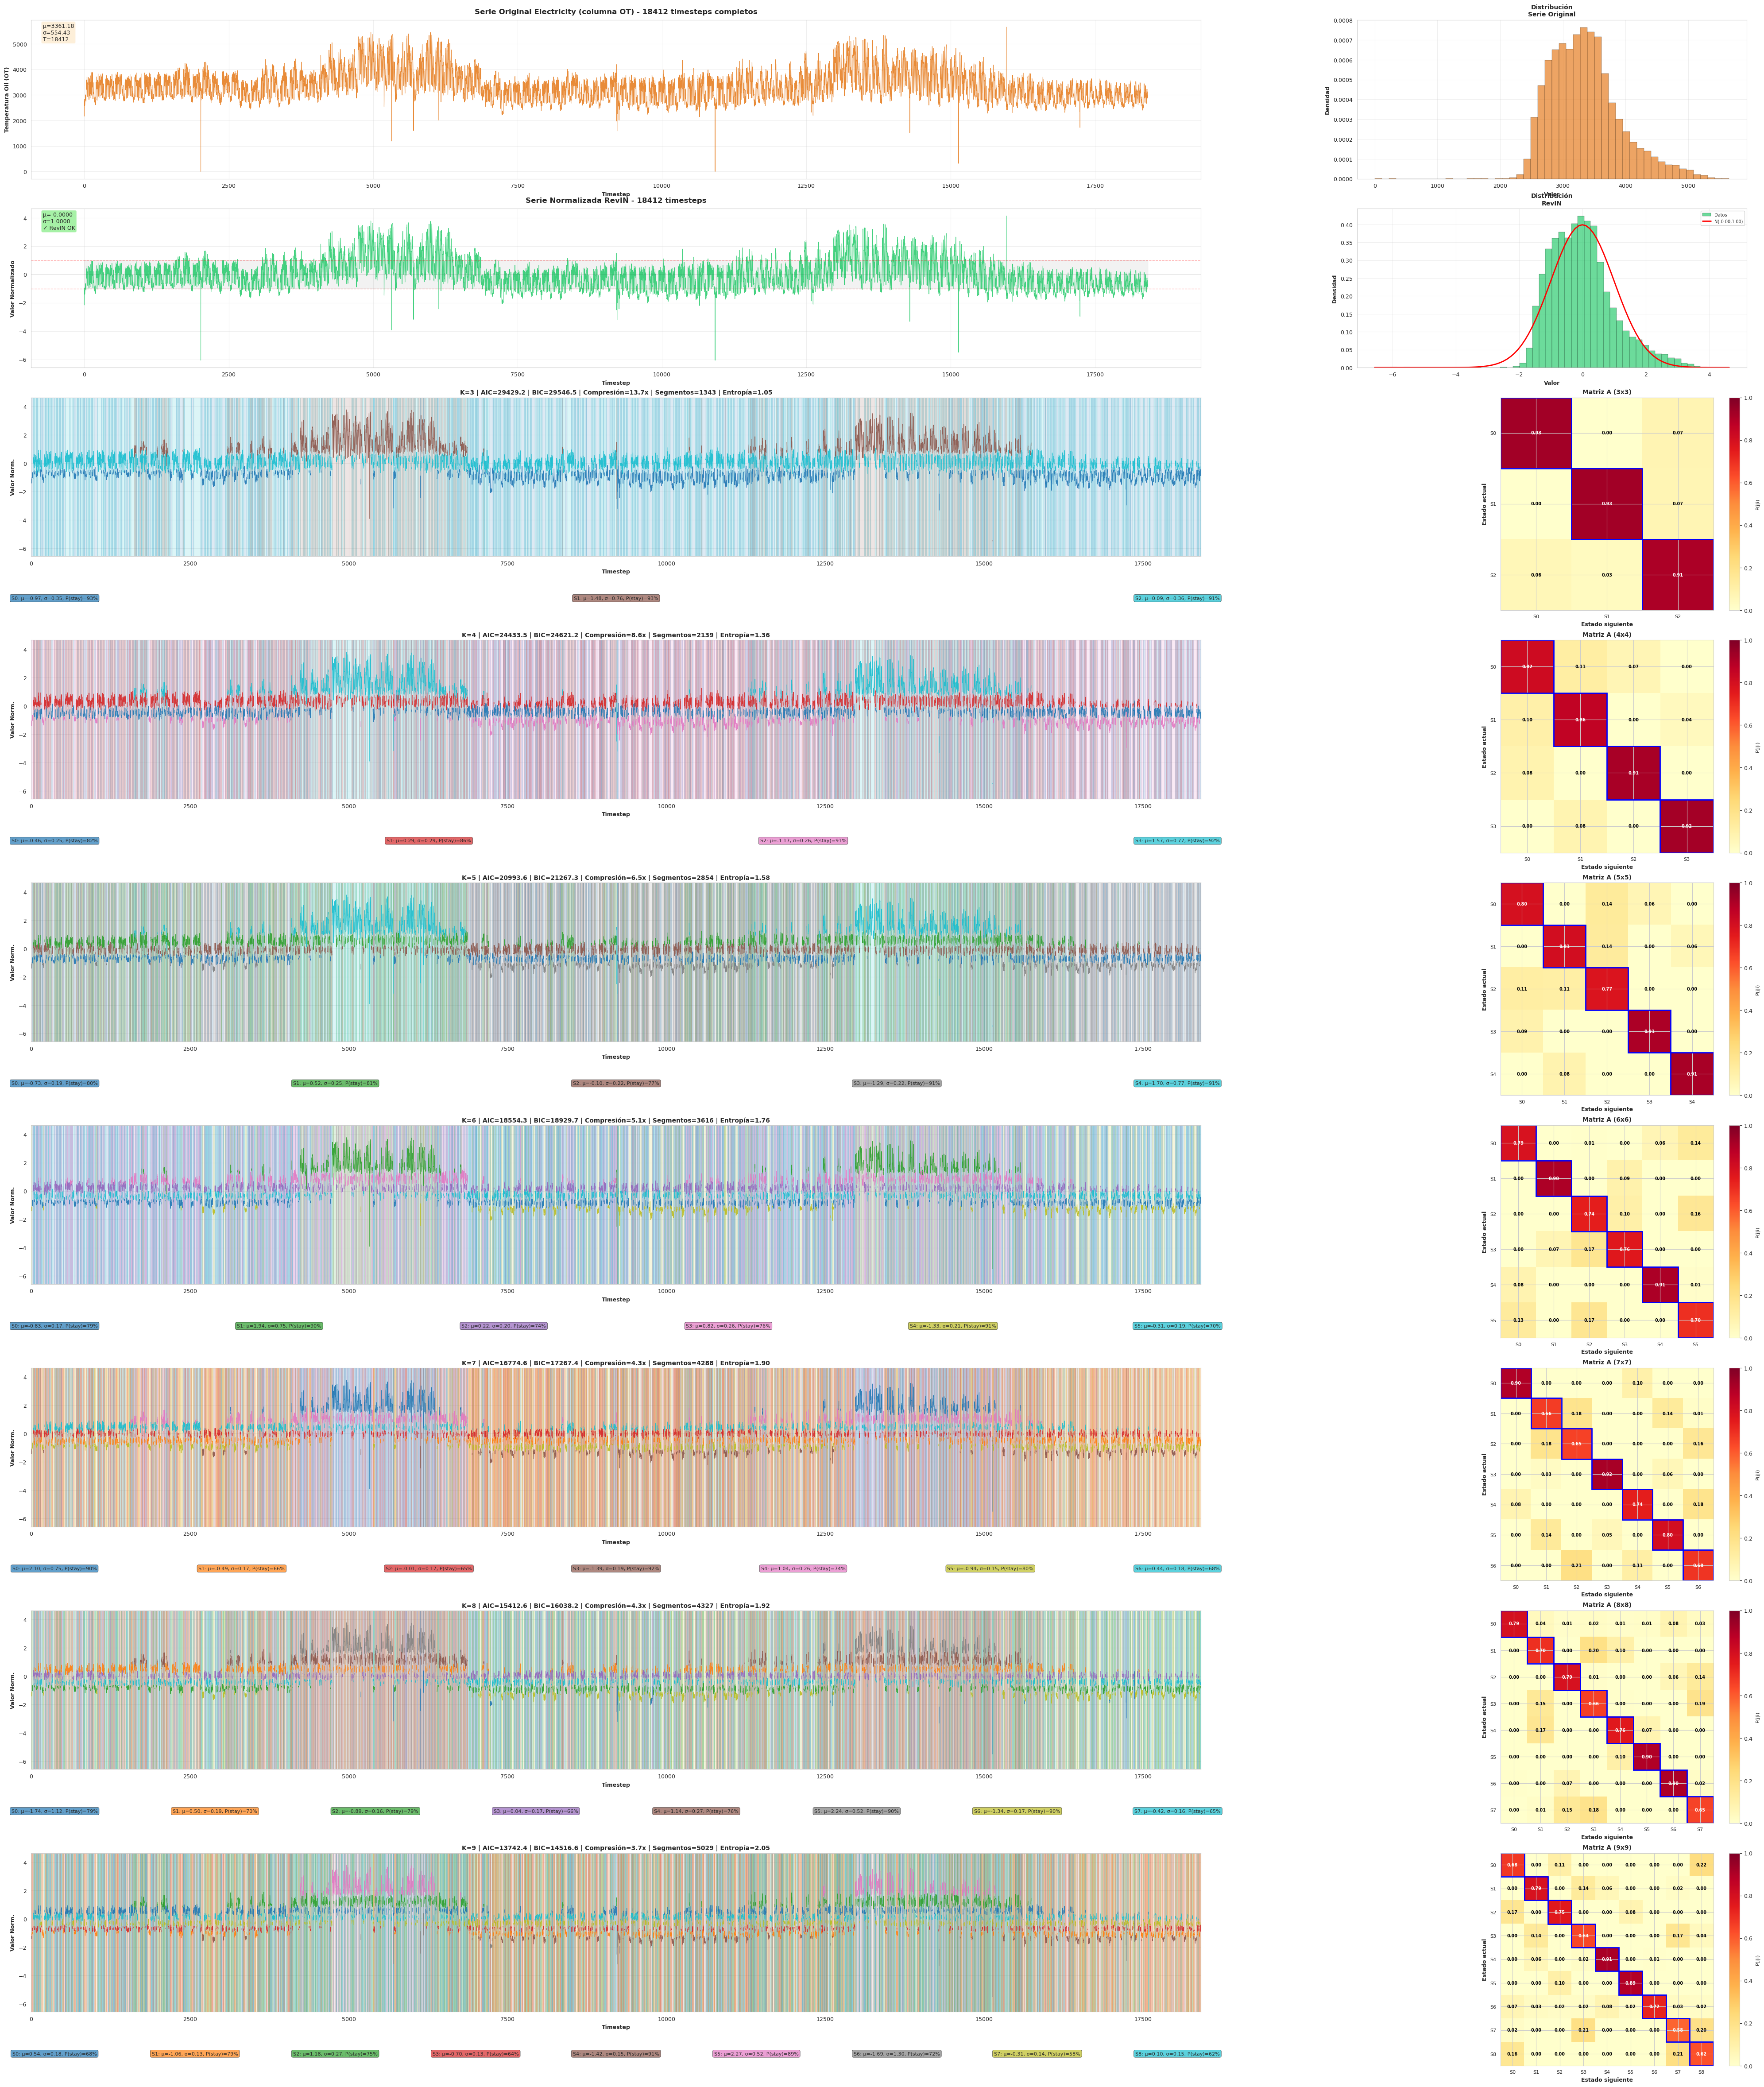

In [6]:
"""Dashboard completo - Validación Pipeline RITMO."""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Rectangle
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 9
plt.rcParams['figure.dpi'] = 100

os.makedirs('./pic', exist_ok=True)

print("\n" + "="*80)
print("GENERANDO DASHBOARD COMPLETO - ETTH2 - TODOS LOS TIMESTEPS")
print("="*80)

def get_segments(states):
    segments = []
    current_state = states[0]
    start_idx = 0
    for i in range(1, len(states)):
        if states[i] != current_state:
            segments.append((start_idx, i, current_state))
            current_state = states[i]
            start_idx = i
    segments.append((start_idx, len(states), current_state))
    return segments

def create_state_legend(ax, K, mu, sigma, A, cmap):
    ax.axis('off')
    x_positions = np.linspace(0.02, 0.98, K)
    for k in range(K):
        color = cmap(k)
        x = x_positions[k]
        text = f"S{k}: μ={mu[k]:.2f}, σ={sigma[k]:.2f}, P(stay)={A[k,k]*100:.0f}%"
        ax.text(x, 0.5, text, ha='center', va='center', fontsize=8,
                transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                         alpha=0.7, edgecolor='black', linewidth=0.5))

# Preparar datos para visualización
configs_to_plot = []
for K in range(3, 10):
    matching = [r for r in results if r['K']==K and r['seed']==42
                and r['data_config']=='full']
    if matching:
        configs_to_plot.append(matching[0])

if len(configs_to_plot) == 0:
    print("⚠ No hay resultados con seed=42 y data=full para visualizar.")
    print("   Ejecuta primero las celdas de K.")
else:
    data_raw_full = configs_to_plot[0]['data_raw']
    data_norm_full = configs_to_plot[0]['data_norm']
    T = len(data_raw_full)

    print(f"Datos preparados: {len(configs_to_plot)} configuraciones (K=3-9)")
    print(f"Timesteps visualizados: {T} (TODOS)")

    n_K = len(configs_to_plot)
    fig = plt.figure(figsize=(50, 60))

    gs_main = fig.add_gridspec(2 + n_K*2, 2, width_ratios=[3, 1],
                               height_ratios=[1, 1] + [1, 0.15]*n_K,
                               hspace=0.3, wspace=0.2)

    print("\nGenerando dashboard...")

    # Serie original
    ax_orig = fig.add_subplot(gs_main[0, 0])
    ax_orig.plot(data_raw_full, color='#e67e22', linewidth=0.8, alpha=0.9)
    ax_orig.set_xlabel('Timestep', fontweight='bold')
    ax_orig.set_ylabel('Temperatura Oil (OT)', fontweight='bold')
    ax_orig.set_title(f'Serie Original Electricity (columna OT) - {T} timesteps completos',
                     fontweight='bold', fontsize=12, pad=10)
    ax_orig.grid(alpha=0.3)

    mean_raw = np.mean(data_raw_full)
    std_raw = np.std(data_raw_full)
    ax_orig.text(0.01, 0.98, f'μ={mean_raw:.2f}\nσ={std_raw:.2f}\nT={T}',
                transform=ax_orig.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='#fdebd0', alpha=0.8))

    ax_hist_orig = fig.add_subplot(gs_main[0, 1])
    ax_hist_orig.hist(data_raw_full, bins=50, density=True, alpha=0.7,
                      color='#e67e22', edgecolor='black', linewidth=0.3)
    ax_hist_orig.set_xlabel('Valor', fontweight='bold')
    ax_hist_orig.set_ylabel('Densidad', fontweight='bold')
    ax_hist_orig.set_title('Distribución\nSerie Original', fontweight='bold', fontsize=10)
    ax_hist_orig.grid(alpha=0.3)

    # Serie normalizada
    ax_norm = fig.add_subplot(gs_main[1, 0])
    ax_norm.plot(data_norm_full, color='#2ecc71', linewidth=0.8, alpha=0.9)
    ax_norm.axhline(y=1, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax_norm.axhline(y=-1, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax_norm.axhline(y=0, color='black', linestyle='-', alpha=0.2, linewidth=0.5)
    ax_norm.fill_between(range(T), -1, 1, alpha=0.1, color='gray')
    ax_norm.set_xlabel('Timestep', fontweight='bold')
    ax_norm.set_ylabel('Valor Normalizado', fontweight='bold')
    ax_norm.set_title(f'Serie Normalizada RevIN - {T} timesteps',
                     fontweight='bold', fontsize=12, pad=10)
    ax_norm.grid(alpha=0.3)

    mean_norm = np.mean(data_norm_full)
    std_norm = np.std(data_norm_full)
    ax_norm.text(0.01, 0.98, f'μ={mean_norm:.4f}\nσ={std_norm:.4f}\n✓ RevIN OK',
                transform=ax_norm.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    ax_hist_norm = fig.add_subplot(gs_main[1, 1])
    ax_hist_norm.hist(data_norm_full, bins=50, density=True, alpha=0.7,
                      color='#2ecc71', edgecolor='black', linewidth=0.3, label='Datos')
    x_theo = np.linspace(data_norm_full.min()-0.5, data_norm_full.max()+0.5, 100)
    y_theo = (1/(std_norm*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_theo-mean_norm)/std_norm)**2)
    ax_hist_norm.plot(x_theo, y_theo, 'r-', linewidth=2, label=f'N({mean_norm:.2f},{std_norm:.2f})')
    ax_hist_norm.set_xlabel('Valor', fontweight='bold')
    ax_hist_norm.set_ylabel('Densidad', fontweight='bold')
    ax_hist_norm.set_title('Distribución\nRevIN', fontweight='bold', fontsize=10)
    ax_hist_norm.legend(fontsize=7)
    ax_hist_norm.grid(alpha=0.3)

    # Series tokenizadas
    for idx, result in enumerate(configs_to_plot):
        K = result['K']
        row_series = 2 + idx * 2
        row_legend = 2 + idx * 2 + 1

        print(f"  Generando K={K}...")

        data_norm = result['data_norm']
        states = result['states']
        mu = result['params']['mu']
        sigma = result['params']['sigma']
        A = result['params']['A']

        cmap = plt.cm.get_cmap('tab10', K)

        ax_series = fig.add_subplot(gs_main[row_series, 0])

        segments = get_segments(states)
        for start, end, k in segments:
            color = cmap(k)
            ax_series.plot(range(start, end), data_norm[start:end],
                          color=color, linewidth=0.8, alpha=0.9)
            ax_series.axvspan(start, end, alpha=0.15, color=color)

        title = (f"K={K} | AIC={result['AIC']:.1f} | BIC={result['BIC']:.1f} | "
                 f"Compresión={result['compression_ratio']:.1f}x | "
                 f"Segmentos={result['n_segments']} | Entropía={result['state_entropy']:.2f}")

        ax_series.set_xlabel('Timestep', fontweight='bold')
        ax_series.set_ylabel('Valor Norm.', fontweight='bold')
        ax_series.set_title(title, fontweight='bold', fontsize=10, pad=5)
        ax_series.grid(alpha=0.3)
        ax_series.set_xlim(0, T)

        ax_legend = fig.add_subplot(gs_main[row_legend, 0])
        create_state_legend(ax_legend, K, mu, sigma, A, cmap)

        ax_matrix = fig.add_subplot(gs_main[row_series:row_series+2, 1])
        im = ax_matrix.imshow(A, cmap='YlOrRd', vmin=0, vmax=1, aspect='equal')

        for i in range(K):
            for j in range(K):
                text_color = 'white' if A[i,j] > 0.5 else 'black'
                ax_matrix.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                              color=text_color, fontsize=7, fontweight='bold')

        for k in range(K):
            rect = Rectangle((k-0.5, k-0.5), 1, 1, fill=False,
                            edgecolor='blue', linewidth=2)
            ax_matrix.add_patch(rect)

        ax_matrix.set_xticks(range(K))
        ax_matrix.set_yticks(range(K))
        ax_matrix.set_xticklabels([f'S{i}' for i in range(K)], fontsize=8)
        ax_matrix.set_yticklabels([f'S{i}' for i in range(K)], fontsize=8)
        ax_matrix.set_xlabel('Estado siguiente', fontweight='bold', fontsize=9)
        ax_matrix.set_ylabel('Estado actual', fontweight='bold', fontsize=9)
        ax_matrix.set_title(f'Matriz A ({K}x{K})', fontweight='bold', fontsize=10)

        cbar = plt.colorbar(im, ax=ax_matrix, fraction=0.046, pad=0.04)
        cbar.set_label('P(j|i)', fontsize=8)

    plt.tight_layout()
    output_path = './pic/dashboard_completo_validacion_ritmo_electricity.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Dashboard guardado en: {output_path}")
    print(f"  Resolución: 50x60 pulgadas @ 150 DPI")
    plt.show()